# Replication of De Cock-Style Housing Price Regression Project Using the Ames Housing Dataset


This project replicates the core regression workflow and project design of the following paper:

De Cock, D. (2011). Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project. *Journal of Statistics Education*, 19(3).

Rather than using the exact 2,930-observation teaching dataset from the original paper, this project uses the [Kaggle Ames Housing data](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) as a close proxy. The original paper can be accessed [here](https://jse.amstat.org/v19n3/decock.pdf). Because of this and a few of my own choices regarding train/validation splits and feature engineering—this should be viewed as a **methodological replication**. The goal is to faithfully recreate the *logic* and process of the original project, rather than perfectly cloning its output.


* **Structure:** I follow the core logic of the original exercise throughout the project. This includes preparing a mixed-type housing dataset, fitting a simple, highly interpretable model (MODEL1) alongside a more flexible, prediction-oriented model (MODEL2), evaluating both on held-out data, and conducting a manual prediction check.
* **Deviations:** Unlike the original classroom setup where splits were inherited, the train-validation split is constructed directly within this project.
* **Extensions:** For transparency, the specific preprocessing choices, derived variables, and exact model specifications are my independent contributions. They are implemented to follow the methodological spirit of the original project rather than acting as a strict line-by-line reproduction.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

OUTPUT_DIR = "/content/final_replication_outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

# 1. Introduction

This project replicates a housing-price prediction project using the Ames, Iowa housing dataset. The main objective is to compare two regression models under a common empirical design: MODEL1 emphasizes interpretability, while MODEL2 emphasizes predictive flexibility. Both models are estimated on the same training sample and evaluated on the same held-out validation sample.

The Ames data contain detailed housing characteristics such as size, quality, age, garage capacity, and neighborhood, while also presenting common modeling issues such as missing values, skewness, and outliers. These features make the dataset suitable for a replication exercise in preprocessing, regression analysis, and out-of-sample validation.

The project is organized as follows. Section 2 describes the data and preprocessing. Section 3 presents the empirical strategy. Section 4 reports the main results and compares MODEL1 and MODEL2 using validation performance.

In [ ]:
# Load the Kaggle Ames Housing training data
df = pd.read_csv("/content/train.csv")

# Basic verification for the next section
print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))
print("Dependent variable present:", "SalePrice" in df.columns)

Dataset shape: (1460, 81)
Number of columns: 81
Dependent variable present: True


This figure summarizes the overall workflow of the replication. The project begins with the Kaggle Ames Housing training data, applies paper-style preprocessing and sample construction, splits the data into training and validation sets, estimates a simpler MODEL1 and a more flexible MODEL2, and then compares the two models using held-out validation metrics.

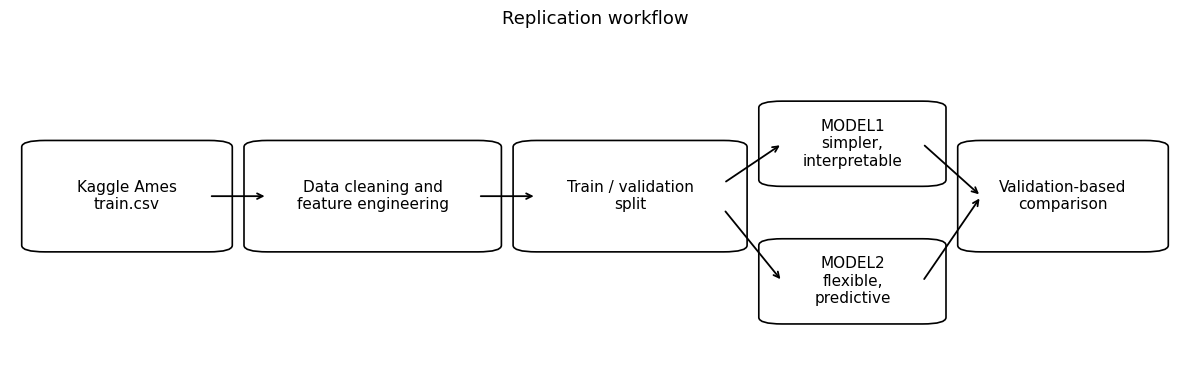

In [ ]:
# Replication workflow
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

boxes = [
    (0.03, 0.35, 0.14, 0.30, "Kaggle Ames\ntrain.csv"),
    (0.22, 0.35, 0.18, 0.30, "Data cleaning and\nfeature engineering"),
    (0.45, 0.35, 0.16, 0.30, "Train / validation\nsplit"),
    (0.66, 0.55, 0.12, 0.22, "MODEL1\nsimpler,\ninterpretable"),
    (0.66, 0.13, 0.12, 0.22, "MODEL2\nflexible,\npredictive"),
    (0.83, 0.35, 0.14, 0.30, "Validation-based\ncomparison")
]

for x, y, w, h, label in boxes:
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=1.2,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=11)

arrowprops = dict(arrowstyle="->", lw=1.3, color="black")

# Main arrows
ax.annotate("", xy=(0.22, 0.50), xytext=(0.17, 0.50), arrowprops=arrowprops)
ax.annotate("", xy=(0.45, 0.50), xytext=(0.40, 0.50), arrowprops=arrowprops)

# Split to MODEL1 and MODEL2
ax.annotate("", xy=(0.66, 0.66), xytext=(0.61, 0.54), arrowprops=arrowprops)
ax.annotate("", xy=(0.66, 0.24), xytext=(0.61, 0.46), arrowprops=arrowprops)

# MODEL1 and MODEL2 to comparison
ax.annotate("", xy=(0.83, 0.50), xytext=(0.78, 0.66), arrowprops=arrowprops)
ax.annotate("", xy=(0.83, 0.50), xytext=(0.78, 0.24), arrowprops=arrowprops)

plt.title("Replication workflow", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "replication_workflow.png"), dpi=300, bbox_inches="tight")
plt.show()

As the figure shows, both models are built from the same cleaned dataset and are evaluated on the same held-out validation sample, so the final comparison reflects differences in model structure rather than differences in data handling.

## 2. Data and Preprocessing

### 2.1 Data source

The analysis uses the Kaggle Ames Housing training dataset (`train.csv`). Although this file is not identical to the full 2,930-observation teaching dataset discussed by De Cock (2011), it contains the same core housing variables and is well suited to a replication of the project’s empirical logic. The response variable is `SalePrice`.

### 2.2 Sample construction

Two initial sample adjustments are made before modeling. First, the identifier variable `Id` is removed because it has no substantive predictive content. Second, observations with `GrLivArea > 4000` are excluded following the conventional outlier rule used in the original project style. After these steps, the remaining sample is divided into training and validation subsets using an 80/20 split.


In [ ]:
# Remove identifier
df_model = df.drop(columns=["Id"]).copy()

# Remove extreme outliers following the paper-style rule
df_model = df_model.loc[df_model["GrLivArea"] <= 4000].copy()

# Define response variables
y_raw = df_model["SalePrice"].copy()
y_log = np.log(y_raw)

# Define raw predictors
X_raw = df_model.drop(columns=["SalePrice"]).copy()

# Train / validation split
X_train_raw, X_valid_raw, y_train_raw, y_valid_raw, y_train_log, y_valid_log = train_test_split(
    X_raw, y_raw, y_log,
    test_size=0.20,
    random_state=42
)

print("Original Kaggle dataset shape:", df.shape)
print("Shape after removing Id and outliers:", df_model.shape)
print("Training rows:", X_train_raw.shape[0])
print("Validation rows:", X_valid_raw.shape[0])
print("Dependent variable:", "SalePrice")
print("Log-transformed response created:", True)

Original Kaggle dataset shape: (1460, 81)
Shape after removing Id and outliers: (1456, 80)
Training rows: 1164
Validation rows: 292
Dependent variable: SalePrice
Log-transformed response created: True


### 2.3 Variable structure

The dataset contains a mixture of numeric, ordinal, and nominal variables. These different variable types require different preprocessing rules. Numeric variables are retained on a quantitative scale, ordinal variables are recoded to preserve ranking information, and nominal variables are converted to indicator variables for regression analysis.

### 2.4 Missing data logic

Missing values are handled according to their economic meaning. In many cases, missingness is structural rather than accidental: for example, missing basement or garage quality often indicates the absence of the feature itself. In such cases, categorical values are recoded as `"None"` and related numeric quantities are set to zero where appropriate. For genuinely missing values, imputation rules are based on training-sample information only, including neighborhood medians for lot frontage and modal categories for selected categorical variables.

### 2.5 Feature engineering

Several derived predictors are constructed to better summarize housing characteristics relevant for pricing. These include total square footage, total bathroom count, and house age, as well as selected amenity indicators. The purpose of these constructed variables is to represent economically meaningful housing attributes more directly than the raw variables alone.

In [ ]:
ordinal_cols = [
    "LotShape", "LandSlope", "OverallQual", "OverallCond", "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "HeatingQC", "KitchenQual", "Functional", "FireplaceQu", "GarageFinish",
    "GarageQual", "GarageCond", "PavedDrive", "PoolQC", "Fence"
]

nominal_cols = [
    "MSZoning", "Street", "Alley", "LandContour", "Utilities", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition", "MSSubClass"
]

structural_categorical_fill_none = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
]

bsmt_numeric_cols = [
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath"
]

garage_numeric_zero_cols = ["GarageCars", "GarageArea"]

qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
bsmt_exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
bsmt_fin_type_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
garage_finish_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
paved_drive_map = {"N": 0, "P": 1, "Y": 2}
lotshape_map = {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3}
landslope_map = {"Sev": 0, "Mod": 1, "Gtl": 2}
functional_map = {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7}
poolqc_map = {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4}
fence_map = {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}

ordinal_mappings = {
    "LotShape": lotshape_map,
    "LandSlope": landslope_map,
    "OverallQual": None,
    "OverallCond": None,
    "ExterQual": qual_map,
    "ExterCond": qual_map,
    "BsmtQual": qual_map,
    "BsmtCond": qual_map,
    "BsmtExposure": bsmt_exposure_map,
    "BsmtFinType1": bsmt_fin_type_map,
    "BsmtFinType2": bsmt_fin_type_map,
    "HeatingQC": qual_map,
    "KitchenQual": qual_map,
    "Functional": functional_map,
    "FireplaceQu": qual_map,
    "GarageFinish": garage_finish_map,
    "GarageQual": qual_map,
    "GarageCond": qual_map,
    "PavedDrive": paved_drive_map,
    "PoolQC": poolqc_map,
    "Fence": fence_map
}

print("Ordinal variables:", len(ordinal_cols))
print("Nominal variables:", len(nominal_cols))
print("Structural categorical fields filled with 'None':", len(structural_categorical_fill_none))

Ordinal variables: 21
Nominal variables: 25
Structural categorical fields filled with 'None': 14


### 2.6 Preprocessing Implementation

Preprocessing is implemented in two stages. First, all imputation rules, recoding decisions, and transformation choices are fit using the training data only. Second, those fitted rules are applied unchanged to both the training and validation sets. This ensures consistency across samples and prevents data leakage from the validation set into model construction.


In [ ]:
def fit_preprocessor(X_train):
    X_fit = X_train.copy()

    for col in structural_categorical_fill_none:
        X_fit[col] = X_fit[col].fillna("None")

    X_fit["MasVnrType"] = X_fit["MasVnrType"].fillna("None")
    mask_mas_none = X_fit["MasVnrType"] == "None"
    X_fit.loc[mask_mas_none & X_fit["MasVnrArea"].isna(), "MasVnrArea"] = 0

    mask_no_bsmt = X_fit["BsmtQual"] == "None"
    for col in bsmt_numeric_cols:
        X_fit.loc[mask_no_bsmt & X_fit[col].isna(), col] = 0

    mask_no_garage = X_fit["GarageType"] == "None"
    for col in garage_numeric_zero_cols:
        X_fit.loc[mask_no_garage & X_fit[col].isna(), col] = 0

    electrical_mode = X_fit["Electrical"].mode(dropna=True)[0]
    neighborhood_lotfront_medians = X_fit.groupby("Neighborhood")["LotFrontage"].median()
    overall_lotfront_median = X_fit["LotFrontage"].median()
    mas_median_non_none = X_fit.loc[X_fit["MasVnrType"] != "None", "MasVnrArea"].median()

    candidate_transform_cols = [
        "LotArea", "LotFrontage", "GrLivArea", "TotalBsmtSF",
        "1stFlrSF", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
        "BsmtUnfSF", "2ndFlrSF", "LowQualFinSF", "WoodDeckSF",
        "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",
        "PoolArea", "MiscVal"
    ]
    existing_candidates = [c for c in candidate_transform_cols if c in X_fit.columns]

    X_tmp = X_fit.copy()
    X_tmp["Electrical"] = X_tmp["Electrical"].fillna(electrical_mode)

    def fill_lotfront_temp(row):
        if pd.isna(row["LotFrontage"]):
            med = neighborhood_lotfront_medians.get(row["Neighborhood"], np.nan)
            if pd.isna(med):
                return overall_lotfront_median
            return med
        return row["LotFrontage"]

    X_tmp["LotFrontage"] = X_tmp.apply(fill_lotfront_temp, axis=1)
    X_tmp["MasVnrArea"] = X_tmp["MasVnrArea"].fillna(mas_median_non_none)

    skew_series = X_tmp[existing_candidates].skew(numeric_only=True).sort_values(ascending=False)
    skewed_to_log1p = [col for col in existing_candidates if skew_series[col] > 0.75]

    nominal_cols_existing = [c for c in nominal_cols if c in X_tmp.columns]
    train_dummy_columns = pd.get_dummies(
        X_tmp,
        columns=nominal_cols_existing,
        drop_first=False,
        dtype=int
    ).columns.tolist()

    return {
        "electrical_mode": electrical_mode,
        "neighborhood_lotfront_medians": neighborhood_lotfront_medians,
        "overall_lotfront_median": overall_lotfront_median,
        "mas_median_non_none": mas_median_non_none,
        "skewed_to_log1p": skewed_to_log1p,
        "train_dummy_columns": train_dummy_columns,
        "nominal_cols_existing": nominal_cols_existing
    }

def transform_with_fitted_preprocessor(X_in, fitted):
    X_out = X_in.copy()

    for col in structural_categorical_fill_none:
        X_out[col] = X_out[col].fillna("None")

    X_out["MasVnrType"] = X_out["MasVnrType"].fillna("None")
    mask_mas_none = X_out["MasVnrType"] == "None"
    X_out.loc[mask_mas_none & X_out["MasVnrArea"].isna(), "MasVnrArea"] = 0

    mask_no_bsmt = X_out["BsmtQual"] == "None"
    for col in bsmt_numeric_cols:
        X_out.loc[mask_no_bsmt & X_out[col].isna(), col] = 0

    mask_no_garage = X_out["GarageType"] == "None"
    for col in garage_numeric_zero_cols:
        X_out.loc[mask_no_garage & X_out[col].isna(), col] = 0

    X_out["Electrical"] = X_out["Electrical"].fillna(fitted["electrical_mode"])

    def fill_lotfront(row):
        if pd.isna(row["LotFrontage"]):
            med = fitted["neighborhood_lotfront_medians"].get(row["Neighborhood"], np.nan)
            if pd.isna(med):
                return fitted["overall_lotfront_median"]
            return med
        return row["LotFrontage"]

    X_out["LotFrontage"] = X_out.apply(fill_lotfront, axis=1)
    X_out["MasVnrArea"] = X_out["MasVnrArea"].fillna(fitted["mas_median_non_none"])

    X_out["HasBsmt"] = (X_out["BsmtQual"] != "None").astype(int)
    X_out["HasGarage"] = (X_out["GarageType"] != "None").astype(int)
    X_out["HasFireplace"] = (X_out["FireplaceQu"] != "None").astype(int)
    X_out["HasPool"] = (X_out["PoolQC"] != "None").astype(int)
    X_out["HasFence"] = (X_out["Fence"] != "None").astype(int)
    X_out["HasMiscFeature"] = (X_out["MiscFeature"] != "None").astype(int)
    X_out["HasMasVnr"] = (X_out["MasVnrType"] != "None").astype(int)

    for col, mapping in ordinal_mappings.items():
        if mapping is not None:
            X_out[col] = X_out[col].map(mapping)

    X_out["FireYN"] = (X_out["Fireplaces"] > 0).astype(int)

    garage_year_fill = X_out.loc[X_out["HasGarage"] == 1, "GarageYrBlt"].median()
    X_out["GarageYrBlt"] = X_out["GarageYrBlt"].fillna(garage_year_fill)

    X_out["TotSF"] = X_out["TotalBsmtSF"] + X_out["GrLivArea"]
    X_out["TotalBath"] = (
        X_out["FullBath"]
        + 0.5 * X_out["HalfBath"]
        + X_out["BsmtFullBath"]
        + 0.5 * X_out["BsmtHalfBath"]
    )
    X_out["HouseAge"] = X_out["YrSold"] - X_out["YearBuilt"]
    X_out["RemodAge"] = X_out["YrSold"] - X_out["YearRemodAdd"]
    X_out["GarageAge"] = np.where(
        X_out["HasGarage"] == 1,
        X_out["YrSold"] - X_out["GarageYrBlt"],
        0
    )
    X_out["TotalPorchSF"] = (
        X_out["OpenPorchSF"]
        + X_out["EnclosedPorch"]
        + X_out["3SsnPorch"]
        + X_out["ScreenPorch"]
    )

    for col in fitted["skewed_to_log1p"]:
        if col in X_out.columns:
            X_out[f"log1p_{col}"] = np.log1p(X_out[col])

    X_out = pd.get_dummies(
        X_out,
        columns=fitted["nominal_cols_existing"],
        drop_first=False,
        dtype=int
    )

    X_out = X_out.reindex(
        columns=fitted["train_dummy_columns"] + [c for c in X_out.columns if c not in fitted["train_dummy_columns"]],
        fill_value=0
    )

    return X_out

In [ ]:
fitted_prep = fit_preprocessor(X_train_raw)

X_train_prep = transform_with_fitted_preprocessor(X_train_raw, fitted_prep)
X_valid_prep = transform_with_fitted_preprocessor(X_valid_raw, fitted_prep)
X_valid_prep = X_valid_prep.reindex(columns=X_train_prep.columns, fill_value=0)

print("Train shape after preprocessing:", X_train_prep.shape)
print("Validation shape after preprocessing:", X_valid_prep.shape)
print("Remaining missing values in training set:", int(X_train_prep.isna().sum().sum()))
print("Remaining missing values in validation set:", int(X_valid_prep.isna().sum().sum()))

Train shape after preprocessing: (1164, 266)
Validation shape after preprocessing: (292, 266)
Remaining missing values in training set: 0
Remaining missing values in validation set: 0


### Table 1. Data Preparation Summary

The following summary table reports the key sample counts and setup choices used in the project. It is intended to give a compact overview of the final analytic sample rather than to reproduce every intermediate preprocessing step.

In [ ]:
table1_data_summary = pd.DataFrame({
    "item": [
        "Original observations",
        "Observations after outlier removal",
        "Training rows",
        "Validation rows",
        "Dependent variable",
        "Response transformation used"
    ],
    "value": [
        int(df.shape[0]),
        int(df_model.shape[0]),
        int(X_train_raw.shape[0]),
        int(X_valid_raw.shape[0]),
        "SalePrice",
        "log(SalePrice)"
    ]
})

table1_data_summary

,item,value
0,Original observations,1460
1,Observations after outlier removal,1456
2,Training rows,1164
3,Validation rows,292
4,Dependent variable,SalePrice
5,Response transformation used,log(SalePrice)


## 3. Empirical Strategy

The goal of this replication is to compare two regression specifications for house prices: a simpler model designed for interpretation and a more flexible model designed for prediction. Both models are estimated on the same training sample and evaluated on the same held-out validation sample so that the comparison is made under a common design.

Let $Y_i$ denote the sale price of house $i$. Because sale prices are strongly right-skewed, the empirical analysis models the logarithm of price rather than the raw level:

$$
y_i = \log(Y_i) = \log(\text{SalePrice}_i).
$$

This transformation reduces skewness and makes the regression specification more stable. After estimation, fitted values are transformed back to the dollar scale for validation.

### 3.1 Validation design

The sample is split into training and validation sets using an 80/20 split. All preprocessing steps are fit on the training data only and then applied unchanged to the validation data. If $T(\cdot)$ denotes the fitted preprocessing rule, then the design is

$$
X_{\text{train}}^{*} = T_{\text{train}}(X_{\text{train}}), \qquad
X_{\text{valid}}^{*} = T_{\text{train}}(X_{\text{valid}}).
$$

This ensures that the validation set remains genuinely out-of-sample and avoids data leakage.

### 3.2 Baseline regression framework

Both models are estimated by ordinary least squares in the general form

$$
y_i = \beta_0 + X_i' \beta + \varepsilon_i,
$$

where $y_i$ is log sale price, $X_i$ is a vector of housing characteristics, and $\varepsilon_i$ is the error term.

The regressors are not used in raw form only. The preprocessing stage constructs meaningful predictors from the Ames data by recoding ordinal variables, dummy-coding nominal variables, handling structural missingness explicitly, and creating derived features such as total square footage and total bath count.


In [ ]:
strategy_summary = pd.DataFrame({
    "item": [
        "Training rows",
        "Validation rows",
        "Training columns after preprocessing",
        "Validation columns after preprocessing",
        "Modeling response",
        "Validation metric scale",
        "Preprocessing fit on training only"
    ],
    "value": [
        int(X_train_prep.shape[0]),
        int(X_valid_prep.shape[0]),
        int(X_train_prep.shape[1]),
        int(X_valid_prep.shape[1]),
        "log(SalePrice)",
        "Raw SalePrice dollars",
        "Yes"
    ]
})

strategy_summary

,item,value
0,Training rows,1164
1,Validation rows,292
2,Training columns after preprocessing,266
3,Validation columns after preprocessing,266
4,Modeling response,log(SalePrice)
5,Validation metric scale,Raw SalePrice dollars
6,Preprocessing fit on training only,Yes


### 3.3 MODEL1

MODEL1 is the simpler specification. It is intended to be interpretable and excludes interaction terms. In this replication, the model takes the form

$$
y_i =
\beta_0
+ \beta_1 \text{OverallQual}_i
+ \beta_2 \text{TotSF}_i
+ \beta_3 \text{GarageCars}_i
+ \beta_4 \text{FullBath}_i
+ \beta_5 \text{HouseAge}_i
+ \beta_6 \text{KitchenQual}_i
+ \sum_{k=1}^{K} \gamma_k N_{ik}
+ \varepsilon_i,
$$

where $N_{ik}$ denotes selected neighborhood dummy variables.

This model serves as the explanatory benchmark. Its structure is intentionally compact so that the direction and relative importance of the main housing characteristics can be interpreted more directly.



The first model is designed to remain compact and interpretable. MODEL1 includes a small set of substantively clear predictors: overall quality, total square footage, garage capacity, number of full bathrooms, house age, and kitchen quality. In addition, five neighborhood indicators are selected using the training data only, based on the strength of their absolute correlation with log sale price, and added to the specification as location controls.


The following code selects the neighborhood controls and constructs the final MODEL1 design matrix.

In [ ]:
# Select the top neighborhood indicators using training data only
neighborhood_cols = [c for c in X_train_prep.columns if c.startswith("Neighborhood_")]
neigh_corr = X_train_prep[neighborhood_cols].corrwith(y_train_log).abs().sort_values(ascending=False)
top_neighborhood_cols = neigh_corr.head(5).index.tolist()

# MODEL1 predictor set
model1_cols = [
    "OverallQual",
    "TotSF",
    "GarageCars",
    "FullBath",
    "HouseAge",
    "KitchenQual"
] + top_neighborhood_cols

X1_train = X_train_prep[model1_cols].copy()
X1_valid = X_valid_prep[model1_cols].copy()

X1_train_sm = sm.add_constant(X1_train)
X1_valid_sm = sm.add_constant(X1_valid, has_constant="add")

print("MODEL1 predictors:")
print(model1_cols)
print("\nMODEL1 training design matrix shape:", X1_train_sm.shape)
print("MODEL1 validation design matrix shape:", X1_valid_sm.shape)

MODEL1 predictors:
['OverallQual', 'TotSF', 'GarageCars', 'FullBath', 'HouseAge', 'KitchenQual', 'Neighborhood_NridgHt', 'Neighborhood_NoRidge', 'Neighborhood_OldTown', 'Neighborhood_IDOTRR', 'Neighborhood_Edwards']

MODEL1 training design matrix shape: (1164, 12)
MODEL1 validation design matrix shape: (292, 12)


### 3.4 MODEL2

MODEL2 is the more flexible specification. It starts from a broader set of strong predictors and then adds selected nonlinear and interaction terms. Its general form is

$$
y_i =
\beta_0
+ \sum_{j=1}^{p} \beta_j x_{ij}
+ \sum_{m=1}^{M} \delta_m x_{im}^2
+ \sum_{r=1}^{R} \theta_r \bigl(x_{ir}^{(1)} x_{ir}^{(2)}\bigr)
+ \varepsilon_i.
$$

In this project, the nonlinear part includes selected squared terms such as

$$
\text{OverallQual}^2,\quad
\text{TotSF}^2,\quad
\text{GrLivArea}^2,\quad
\text{HouseAge}^2,\quad
\text{TotalBath}^2,
$$

and the interaction part includes terms such as

$$
\text{OverallQual} \times \text{TotSF}, \qquad
\text{OverallQual} \times \text{HouseAge}, \qquad
\text{GarageCars} \times \text{TotSF}.
$$

This added complexity is intentional. The original project emphasizes that a more flexible model may improve predictive performance even when coefficient-by-coefficient interpretation becomes less clean. Accordingly, MODEL2 is treated here as the more prediction-oriented specification.


I then constructs the selected nonlinear and interaction terms used in MODEL2 from the training-based predictor set.


In [ ]:
numeric_train = X_train_prep.select_dtypes(include=[np.number]).copy()
corrs_model2 = numeric_train.corrwith(y_train_log).abs().sort_values(ascending=False)
top20_cols = corrs_model2.head(20).index.tolist()

X2_train = X_train_prep[top20_cols].copy()
X2_valid = X_valid_prep[top20_cols].copy()

# Selected quadratic terms
quadratic_candidates = [c for c in ["OverallQual", "TotSF", "GrLivArea", "HouseAge", "TotalBath"] if c in X2_train.columns]
for col in quadratic_candidates:
    X2_train[f"{col}_sq"] = X2_train[col] ** 2
    X2_valid[f"{col}_sq"] = X2_valid[col] ** 2

# Selected interaction terms
interaction_pairs = []
if "OverallQual" in X2_train.columns and "TotSF" in X2_train.columns:
    interaction_pairs.append(("OverallQual", "TotSF"))
if "OverallQual" in X2_train.columns and "HouseAge" in X2_train.columns:
    interaction_pairs.append(("OverallQual", "HouseAge"))
if "GarageCars" in X2_train.columns and "TotSF" in X2_train.columns:
    interaction_pairs.append(("GarageCars", "TotSF"))

for a, b in interaction_pairs:
    X2_train[f"{a}_x_{b}"] = X2_train[a] * X2_train[b]
    X2_valid[f"{a}_x_{b}"] = X2_valid[a] * X2_valid[b]

X2_train_sm = sm.add_constant(X2_train)
X2_valid_sm = sm.add_constant(X2_valid, has_constant="add")

print("MODEL2 top-20 base predictors:")
print(top20_cols)
print("\nMODEL2 quadratic terms:")
print([f"{c}_sq" for c in quadratic_candidates])
print("\nMODEL2 interaction terms:")
print([f"{a}_x_{b}" for a, b in interaction_pairs])
print("\nMODEL2 training design matrix shape:", X2_train_sm.shape)
print("MODEL2 validation design matrix shape:", X2_valid_sm.shape)

MODEL2 top-20 base predictors:
['TotSF', 'OverallQual', 'log1p_GrLivArea', 'GrLivArea', 'GarageCars', 'TotalBath', 'ExterQual', 'KitchenQual', 'GarageArea', 'TotalBsmtSF', 'BsmtQual', 'GarageFinish', '1stFlrSF', 'log1p_1stFlrSF', 'HouseAge', 'YearBuilt', 'FullBath', 'RemodAge', 'YearRemodAdd', 'FireplaceQu']

MODEL2 quadratic terms:
['OverallQual_sq', 'TotSF_sq', 'GrLivArea_sq', 'HouseAge_sq', 'TotalBath_sq']

MODEL2 interaction terms:
['OverallQual_x_TotSF', 'OverallQual_x_HouseAge', 'GarageCars_x_TotSF']

MODEL2 training design matrix shape: (1164, 29)
MODEL2 validation design matrix shape: (292, 29)


### 3.5 Predictor transformations

For selected skewed predictors, the project applies the transformation

$$
x_i^{*} = \log(1 + x_i),
$$

which is suitable for nonnegative variables that may include zero values. This transformation is used for variables such as lot size, lot frontage, and selected area measures when skewness is sufficiently high in the training data. The transformed variables are then entered as additional regressors in the modeling stage.

### 3.6 Evaluation criteria

Model comparison is based on both fit and out-of-sample predictive performance. Although training fit is summarized using measures such as $R^2$, the more important comparison is based on held-out validation results.

If $\widehat{y}_i$ denotes the fitted value on the log scale, the corresponding prediction on the original dollar scale is

$$
\widehat{Y}_i = \exp(\widehat{y}_i).
$$

Let $Y_i$ denote the observed sale price and $\widehat{Y}_i$ the predicted sale price for validation observation $i$. The paper-style validation measures are:

$$
\text{Bias} = \frac{1}{n}\sum_{i=1}^{n}(\widehat{Y}_i - Y_i),
$$

$$
\text{Maximum Deviation} = \max_{1 \le i \le n} \left| \widehat{Y}_i - Y_i \right|,
$$

$$
\text{Mean Absolute Deviation} = \frac{1}{n}\sum_{i=1}^{n}\left| \widehat{Y}_i - Y_i \right|,
$$

$$
\text{Mean Square Error} = \frac{1}{n}\sum_{i=1}^{n}(\widehat{Y}_i - Y_i)^2.
$$

For additional comparison, the project also reports validation RMSE and mean absolute error. These criteria make it possible to compare the cleaner interpretability of MODEL1 with the stronger predictive flexibility of MODEL2 without relying only on in-sample fit.

In [ ]:
empirical_strategy_table = pd.DataFrame({
    "component": [
        "Validation design",
        "Training share",
        "Validation share",
        "Response used in model fitting",
        "Prediction scale for final comparison",
        "MODEL1 style",
        "MODEL2 style",
        "Core validation metrics"
    ],
    "description": [
        "Hold-out train/validation split",
        "80%",
        "20%",
        "log(SalePrice)",
        "Raw SalePrice dollars",
        "Simpler, more interpretable specification",
        "More flexible, prediction-oriented specification",
        "Bias, Maximum Deviation, Mean Absolute Deviation, Mean Square Error"
    ]
})

empirical_strategy_table

,component,description
0,Validation design,Hold-out train/validation split
1,Training share,80%
2,Validation share,20%
3,Response used in model fitting,log(SalePrice)
4,Prediction scale for final comparison,Raw SalePrice dollars
5,MODEL1 style,"Simpler, more interpretable specification"
6,MODEL2 style,"More flexible, prediction-oriented specification"
7,Core validation metrics,"Bias, Maximum Deviation, Mean Absolute Deviati..."


## 4. Results

This section presents the main empirical results of the replication. It begins with the distributional evidence that motivates the outlier rule and the log transformation of the response, then reports the fitted results for the two competing regression models. Following the spirit of the original project, the section also includes a manual reconstruction of one fitted value and concludes with a validation-based comparison of MODEL1 and MODEL2 on the raw dollar scale.


### 4.1 Data and distributional evidence


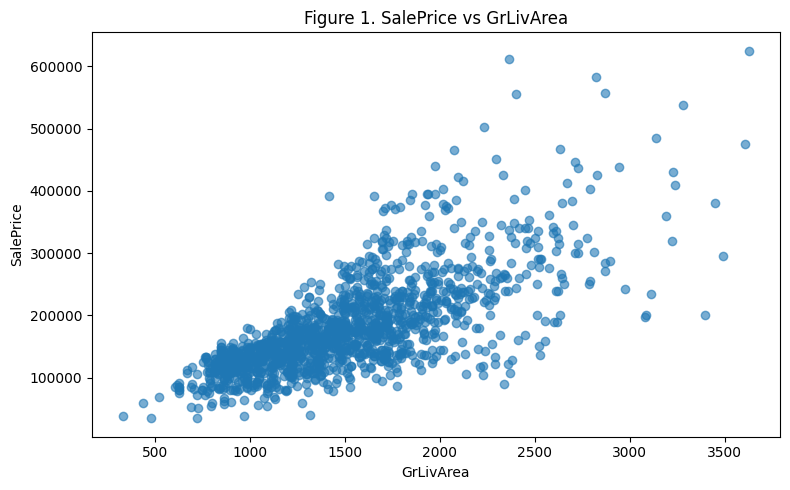

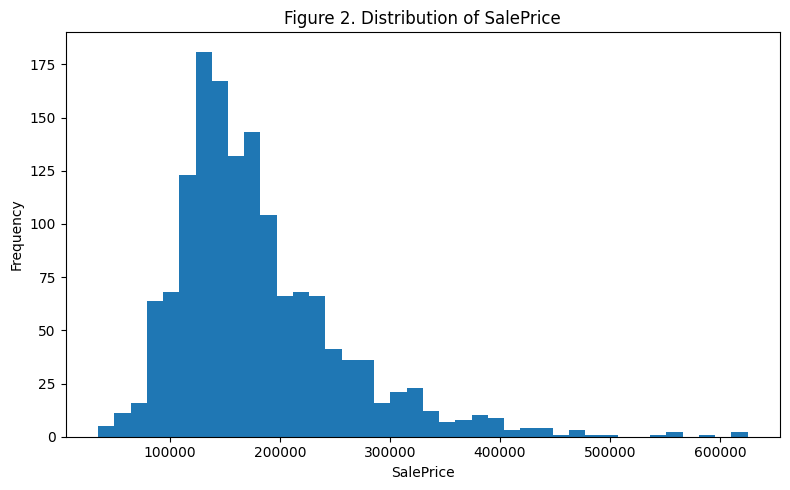

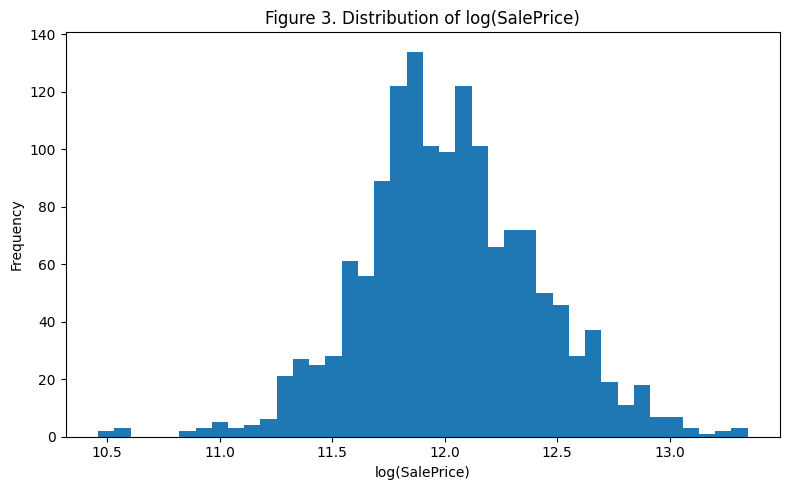

In [ ]:
# Figure 1: SalePrice vs GrLivArea
plt.figure(figsize=(8, 5))
plt.scatter(df_model["GrLivArea"], df_model["SalePrice"], alpha=0.6)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Figure 1. SalePrice vs GrLivArea")
plt.tight_layout()
plt.show()

# Figure 2: Distribution of SalePrice
plt.figure(figsize=(8, 5))
plt.hist(y_raw, bins=40)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Figure 2. Distribution of SalePrice")
plt.tight_layout()
plt.show()

# Figure 3: Distribution of log(SalePrice)
plt.figure(figsize=(8, 5))
plt.hist(y_log, bins=40)
plt.xlabel("log(SalePrice)")
plt.ylabel("Frequency")
plt.title("Figure 3. Distribution of log(SalePrice)")
plt.tight_layout()
plt.show()

Before estimating the two models, it is useful to examine the basic relationship between housing size and sale price, as well as the shape of the response distribution. Figure 1 plots `SalePrice` against `GrLivArea`, which serves as one of the key size-related variables in the dataset. The figure shows a strong positive association between above-grade living area and housing price, but it also reveals a small number of unusually large homes that lie well outside the main cloud of observations. This visual pattern supports the paper-style outlier rule that removes observations with `GrLivArea > 4000` from the analytic sample.

Figure 2 shows the distribution of the raw response variable, $SalePrice$. The distribution is clearly right-skewed, with a long upper tail. Such skewness is common in housing-price data and may create problems for a linear model estimated directly on the raw scale, especially because very expensive homes can dominate the fit and generate non-constant error variance.

To reduce this problem, the  models the transformed response

$$
y_i = \log(SalePrice_i).
$$

Figure 3 shows the distribution of $\log(SalePrice)$. Relative to the raw-scale distribution, the transformed response is much closer to symmetry. This makes the log specification a more suitable dependent variable for linear regression and aligns with standard practice in applied housing-price modeling. For this reason, both MODEL1 and MODEL2 are estimated on the log-price scale, while prediction accuracy is later evaluated after transforming fitted values back into dollars.


### 4.2 Results for MODEL1

MODEL1 is the simpler of the two specifications and is intended to serve as an interpretable benchmark. Its fitted form can be written as

$$
\log(SalePrice_i)
=
\beta_0
+
\beta_1 OverallQual_i
+
\beta_2 TotSF_i
+
\beta_3 GarageCars_i
+
\beta_4 FullBath_i
+
\beta_5 HouseAge_i
+
\beta_6 KitchenQual_i
+
\sum_{m=1}^{M}\delta_m Neighborhood_{im}
+
\varepsilon_i,
$$

where the neighborhood terms are a small set of indicator variables selected from the training data.

In [ ]:
model1 = sm.OLS(y_train_log, X1_train_sm).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     646.0
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:54:43   Log-Likelihood:                 574.98
No. Observations:                1164   AIC:                            -1126.
Df Residuals:                    1152   BIC:                            -1065.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.6164 

In [ ]:
table2_model1_results = pd.DataFrame({
    "variable": model1.params.index,
    "coefficient": model1.params.values,
    "std_error": model1.bse.values,
    "p_value": model1.pvalues.values
})

table2_model1_results

,variable,coefficient,std_error,p_value
0,const,10.616437,0.037555,0.000000e+00
1,OverallQual,0.082335,0.005524,4.465752e-46
2,TotSF,0.000229,0.000009,4.388849e-114
3,GarageCars,0.068757,0.008212,1.617019e-16
4,FullBath,0.000005,0.010509,9.996091e-01
5,HouseAge,-0.000903,0.000234,1.208052e-04
6,KitchenQual,0.070971,0.009408,9.250650e-14
7,Neighborhood_NridgHt,0.015234,0.021001,4.683716e-01
8,Neighborhood_NoRidge,0.039633,0.027469,1.493421e-01
9,Neighborhood_OldTown,-0.134892,0.019630,1.037351e-11


Table 2 reports the estimated coefficients for MODEL1. The fitted results are economically sensible. Overall quality enters positively, implying that better construction and finish quality are associated with higher house values. Total square footage also enters positively, which is consistent with the idea that larger homes command higher prices. Garage capacity and kitchen quality are likewise positively associated with housing value, while house age enters negatively, suggesting that older houses tend to sell for less after controlling for the other characteristics in the model.


In [ ]:
def run_diagnostics(model, fitted_log, y_log_true, model_name):
    residuals = y_log_true - fitted_log
    influence = OLSInfluence(model)

    cooks_d = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag
    std_resid = influence.resid_studentized_internal

    influence_df = pd.DataFrame({
        "index": model.model.data.row_labels,
        "cooks_d": cooks_d,
        "leverage": leverage,
        "std_resid": std_resid
    }).sort_values("cooks_d", ascending=False)

    # Residuals vs fitted
    plt.figure(figsize=(7, 5))
    plt.scatter(fitted_log, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Fitted values (log scale)")
    plt.ylabel("Residuals")
    plt.title(f"{model_name}: Residuals vs Fitted")
    plt.tight_layout()
    plt.show()

    # Q-Q plot
    qqplot(residuals, line="45", fit=True)
    plt.title(f"{model_name}: Q-Q Plot")
    plt.tight_layout()
    plt.show()

    return influence_df, residuals

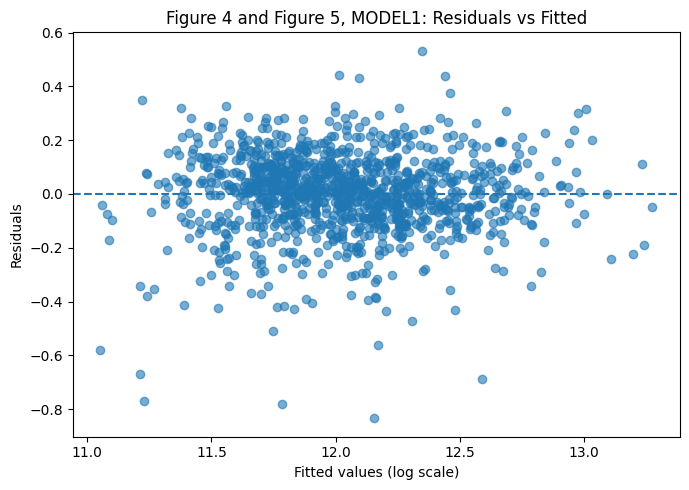

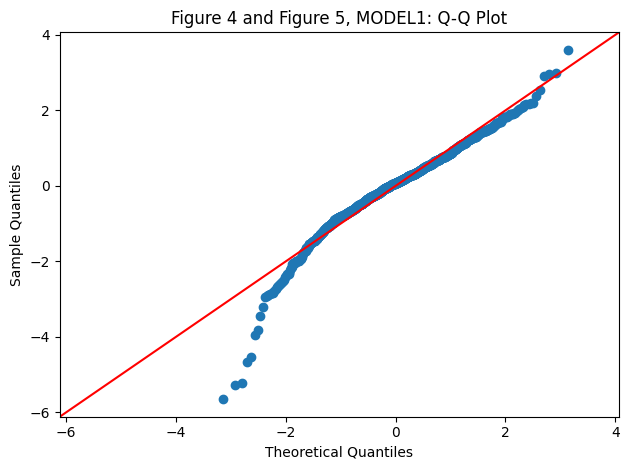

Top 10 influential observations for MODEL1


,index,cooks_d,leverage,std_resid
495,495,0.089820,0.037074,-5.291034
916,916,0.069068,0.048784,-4.020022
410,410,0.035822,0.015091,-5.296657
968,968,0.031445,0.017936,-4.545430
1325,1325,0.018884,0.037087,-2.425614
607,607,0.017738,0.040761,2.238112
676,676,0.017551,0.025245,-2.851741
1279,1279,0.016832,0.039417,-2.218616
728,728,0.013869,0.011320,-3.812541
1223,1223,0.013091,0.014999,-3.211883


In [ ]:
yhat1_train_log = model1.predict(X1_train_sm)
yhat1_valid_log = model1.predict(X1_valid_sm)

model1_influence_df, model1_residuals = run_diagnostics(
    model1, yhat1_train_log, y_train_log, "Figure 4 and Figure 5, MODEL1"
)

print("Top 10 influential observations for MODEL1")
display(model1_influence_df.head(10))

MODEL1 also achieves a strong in-sample fit for a compact specification. This indicates that a relatively small set of structural and locational variables explains a large share of the variation in log housing prices. That is exactly the role MODEL1 is meant to play in the project: it is not the most flexible model, but it is easy to interpret and already captures the major price determinants.

The diagnostic plots provide a further check on the adequacy of the specification. Figure 4 plots residuals against fitted values for MODEL1. The residuals are centered around zero, but the spread is not perfectly constant and some structure remains, indicating that the model does not fully capture all nonlinearities in the data. Figure 5 presents the normal Q–Q plot of the residuals. The middle of the distribution tracks the reference line reasonably well, but the tails depart from it, suggesting that residual normality is only approximate. Taken together, the diagnostics imply that MODEL1 performs well as an explanatory benchmark, though it does not eliminate all specification error.

### 4.3 Manual model check

A central requirement of the original project is that at least one fitted value should be verified manually rather than accepted only from software output. For a single observation $i$, the fitted value on the log scale is

$$
\widehat{y}_i
=
\widehat{\beta}_0
+
\sum_{j=1}^{k} x_{ij}\widehat{\beta}_j,
$$

where $x_{ij}$ denotes the observed value of regressor $j$ for observation $i$, and $\widehat{\beta}_j$ denotes the estimated coefficient from MODEL1.

Because the model is estimated on the logarithmic scale, the corresponding fitted value in dollars is obtained by exponentiation:

$$
\widehat{Y}_i = \exp(\widehat{y}_i).
$$


In [ ]:
obs_idx = X1_train.index[0]
x_obs = X1_train.iloc[0].copy()

x_obs_with_const = pd.Series(
    [1.0] + x_obs.tolist(),
    index=["const"] + list(x_obs.index)
)

beta = model1.params.copy()

manual_log_pred = float((x_obs_with_const * beta).sum())
manual_raw_pred = float(np.exp(manual_log_pred))

model_log_pred = float(model1.predict(X1_train_sm.iloc[[0]]).iloc[0])
model_raw_pred = float(np.exp(model_log_pred))

table3_manual_check = pd.DataFrame({
    "term": x_obs_with_const.index,
    "value": x_obs_with_const.values,
    "coefficient": beta.values,
    "contribution": x_obs_with_const.values * beta.values
})

print("Manual log prediction:", manual_log_pred)
print("Model log prediction :", model_log_pred)
print("Difference (log scale):", manual_log_pred - model_log_pred)
print()
print("Manual raw prediction:", manual_raw_pred)
print("Model raw prediction :", model_raw_pred)
print("Difference (raw scale):", manual_raw_pred - model_raw_pred)

table3_manual_check

Manual log prediction: 11.863882716935684
Model log prediction : 11.863882716935684
Difference (log scale): 0.0

Manual raw prediction: 142042.66041687946
Model raw prediction : 142042.66041687946
Difference (raw scale): 0.0


,term,value,coefficient,contribution
0,const,1.0,10.616437,10.616437
1,OverallQual,5.0,0.082335,0.411673
2,TotSF,2628.0,0.000229,0.601938
3,GarageCars,1.0,0.068757,0.068757
4,FullBath,1.0,0.000005,0.000005
5,HouseAge,53.0,-0.000903,-0.047842
6,KitchenQual,3.0,0.070971,0.212914
7,Neighborhood_NridgHt,0.0,0.015234,0.000000
8,Neighborhood_NoRidge,0.0,0.039633,0.000000
9,Neighborhood_OldTown,0.0,-0.134892,-0.000000


Table 3 shows the contribution of each term in the selected observation’s prediction. The manually reconstructed log prediction matches the software-generated fitted value exactly, and the same is true after transforming back to the raw dollar scale. This confirms that the fitted MODEL1 equation is being interpreted correctly and that the project’s implementation is internally consistent.


### 4.4 Results for MODEL2

MODEL2 is constructed to be more flexible and more prediction-oriented than MODEL1. It starts from a broader set of strong numeric predictors from the training data and then adds selected quadratic and interaction terms. In compact form, the model can be written as

$$
\log(SalePrice_i)
=
\beta_0
+
X_i' \beta
+
Q_i' \gamma
+
Z_i' \delta
+
\varepsilon_i,
$$

where $X_i$ contains the base predictors, $Q_i$ contains the quadratic terms, and $Z_i$ contains the interaction terms.



In [ ]:
model2 = sm.OLS(y_train_log, X2_train_sm).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     350.8
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:54:43   Log-Likelihood:                 708.83
No. Observations:                1164   AIC:                            -1364.
Df Residuals:                    1137   BIC:                            -1227.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6

In [ ]:
table4_model2_results = pd.DataFrame({
    "variable": model2.params.index,
    "coefficient": model2.params.values,
    "std_error": model2.bse.values,
    "p_value": model2.pvalues.values
})

table4_model2_results

,variable,coefficient,std_error,p_value
0,const,6.387093e+00,6.107772e+00,2.959070e-01
1,TotSF,-2.650582e-04,8.580411e-05,2.056296e-03
2,OverallQual,7.160100e-02,3.154198e-02,2.339275e-02
3,log1p_GrLivArea,6.789624e-01,1.954470e-01,5.322683e-04
4,GrLivArea,-4.216781e-04,1.646145e-04,1.054693e-02
5,GarageCars,2.295424e-02,2.560222e-02,3.701371e-01
6,TotalBath,5.574445e-02,2.915095e-02,5.609281e-02
7,ExterQual,2.708424e-02,1.223828e-02,2.709045e-02
8,KitchenQual,3.619464e-02,9.608535e-03,1.737386e-04
9,GarageArea,1.516086e-04,4.202247e-05,3.222213e-04


This richer structure allows MODEL2 to capture nonlinear and joint effects that are ruled out in MODEL1. For example, the effect of housing quality may vary with total area, and the marginal effect of age may not be constant across the support of the data. By including such terms directly, MODEL2 is designed to improve predictive fit even if the resulting coefficient structure becomes harder to interpret.

Table 4 reports the estimated results for MODEL2. Relative to MODEL1, the richer specification achieves a stronger in-sample fit. Several of the added terms contribute meaningfully to the model, including selected transformed size variables, quadratic terms, and interaction terms. This is consistent with the idea that housing prices are shaped by more than a purely additive linear relationship among the main covariates.


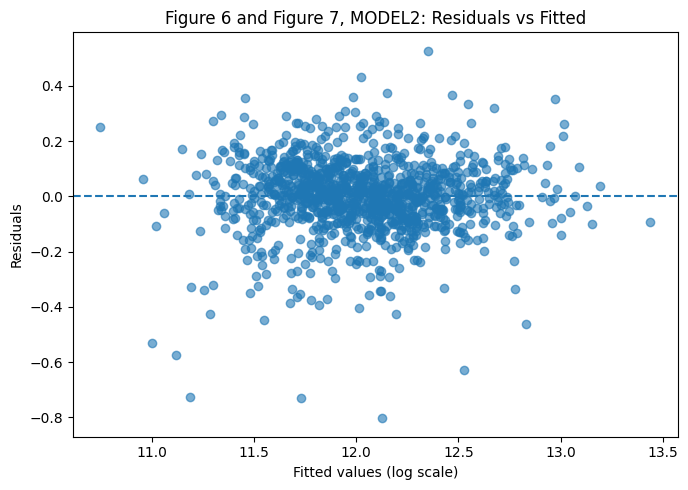

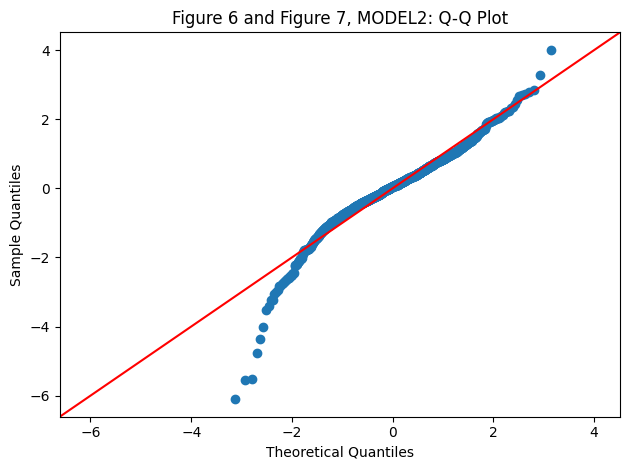

Top 10 influential observations for MODEL2


,index,cooks_d,leverage,std_resid
916,916,0.109909,0.146997,-4.300661
1100,1100,0.034523,0.185596,2.095974
197,197,0.031553,0.066272,-3.590578
495,495,0.027338,0.025279,-5.528987
968,968,0.026477,0.038046,-4.406135
710,710,0.019550,0.050229,-3.274193
632,632,0.018879,0.014606,-6.077636
1349,1349,0.018059,0.173057,-1.581935
457,457,0.015454,0.039433,3.304105
1244,1244,0.015376,0.054502,2.781316


In [ ]:
yhat2_train_log = model2.predict(X2_train_sm)
yhat2_valid_log = model2.predict(X2_valid_sm)

model2_influence_df, model2_residuals = run_diagnostics(
    model2, yhat2_train_log, y_train_log, "Figure 6 and Figure 7, MODEL2"
)

print("Top 10 influential observations for MODEL2")
display(model2_influence_df.head(10))

The diagnostic plots again show both strengths and weaknesses of the model. Figure 6 plots residuals against fitted values for MODEL2. Compared with MODEL1, the residual variation is somewhat tighter, which is consistent with the better fit of the richer specification. Figure 7 presents the Q–Q plot. Although departures from normality remain in the tails, the overall pattern is reasonably close to the reference line in the center of the distribution. Thus, MODEL2 improves fit, but it does not completely solve the non-normality and tail-behavior issues that are common in housing-price regressions.

In [ ]:
yhat1_train_raw = np.exp(yhat1_train_log)
yhat1_valid_raw = np.exp(yhat1_valid_log)
yhat2_train_raw = np.exp(yhat2_train_log)
yhat2_valid_raw = np.exp(yhat2_valid_log)

quick_comparison_table = pd.DataFrame({
    "model": ["MODEL1", "MODEL1", "MODEL2", "MODEL2"],
    "dataset": ["train", "valid", "train", "valid"],
    "RMSE": [
        np.sqrt(np.mean((y_train_raw - yhat1_train_raw) ** 2)),
        np.sqrt(np.mean((y_valid_raw - yhat1_valid_raw) ** 2)),
        np.sqrt(np.mean((y_train_raw - yhat2_train_raw) ** 2)),
        np.sqrt(np.mean((y_valid_raw - yhat2_valid_raw) ** 2)),
    ],
    "MAE": [
        np.mean(np.abs(y_train_raw - yhat1_train_raw)),
        np.mean(np.abs(y_valid_raw - yhat1_valid_raw)),
        np.mean(np.abs(y_train_raw - yhat2_train_raw)),
        np.mean(np.abs(y_valid_raw - yhat2_valid_raw)),
    ]
})

quick_comparison_table

,model,dataset,RMSE,MAE
0,MODEL1,train,27756.229285,19164.948893
1,MODEL1,valid,26318.558542,19341.452727
2,MODEL2,train,24385.222114,16499.562766
3,MODEL2,valid,24253.839530,17426.390180


At the same time, the gain in flexibility comes at a cost. Because MODEL2 contains more highly related predictors, including transformations and interaction terms, it is more exposed to multicollinearity and less suited to clean coefficient-by-coefficient interpretation. For that reason, MODEL2 is best treated as the predictive model in the comparison, whereas MODEL1 remains the clearer explanatory benchmark.


### 4.5 Validation comparison

The most important comparison in the project is not based solely on in-sample fit, but on predictive performance in the held-out validation sample. Let $Y_i$ denote the observed sale price in dollars and let $\widehat{Y}_i$ denote the back-transformed prediction from the fitted log model:

$$
\widehat{Y}_i = \exp(\widehat{y}_i).
$$

Using these raw-scale predictions, the project evaluates model performance through the validation measures emphasized in the original project. For a validation sample of size $n$, these are defined as

$$
\text{Bias}
=
\frac{1}{n}\sum_{i=1}^{n}(\widehat{Y}_i - Y_i),
$$

$$
\text{Maximum Deviation}
=
\max_{1 \le i \le n} |\widehat{Y}_i - Y_i|,
$$

$$
\text{Mean Absolute Deviation}
=
\frac{1}{n}\sum_{i=1}^{n} |\widehat{Y}_i - Y_i|,
$$

and

$$
\text{Mean Square Error}
=
\frac{1}{n}\sum_{i=1}^{n}(\widehat{Y}_i - Y_i)^2.
$$


In [ ]:
def paper_metrics(y_true_raw, y_pred_raw):
    error = y_pred_raw - y_true_raw
    abs_error = np.abs(y_true_raw - y_pred_raw)

    return {
        "Bias": float(np.mean(error)),
        "Maximum Deviation": float(np.max(abs_error)),
        "Mean Absolute Deviation": float(np.mean(abs_error)),
        "Mean Square Error": float(np.mean((y_true_raw - y_pred_raw) ** 2))
    }

model1_valid_paper = paper_metrics(y_valid_raw, yhat1_valid_raw)
model2_valid_paper = paper_metrics(y_valid_raw, yhat2_valid_raw)

table5_validation_metrics = pd.DataFrame({
    "metric": ["Bias", "Maximum Deviation", "Mean Absolute Deviation", "Mean Square Error"],
    "MODEL1_valid": [
        model1_valid_paper["Bias"],
        model1_valid_paper["Maximum Deviation"],
        model1_valid_paper["Mean Absolute Deviation"],
        model1_valid_paper["Mean Square Error"]
    ],
    "MODEL2_valid": [
        model2_valid_paper["Bias"],
        model2_valid_paper["Maximum Deviation"],
        model2_valid_paper["Mean Absolute Deviation"],
        model2_valid_paper["Mean Square Error"]
    ]
})

table5_validation_metrics

,metric,MODEL1_valid,MODEL2_valid
0,Bias,-9.857620e+02,-1.250660e+03
1,Maximum Deviation,1.162102e+05,1.059940e+05
2,Mean Absolute Deviation,1.934145e+04,1.742639e+04
3,Mean Square Error,6.926665e+08,5.882487e+08


Table 5 reports these validation metrics for MODEL1 and MODEL2. The results show that MODEL2 outperforms MODEL1 on the held-out sample. In particular, MODEL2 achieves lower validation RMSE and lower mean absolute error, and it also improves on the project’s paper-style measures such as mean absolute deviation and mean square error. This indicates that the additional flexibility in MODEL2 translates into better out-of-sample prediction rather than merely better in-sample fit.

In [ ]:
table6_final_comparison = pd.DataFrame({
    "criterion": [
        "Interpretability",
        "Training R-squared",
        "Validation RMSE",
        "Validation MAE",
        "Validation Bias",
        "Validation Maximum Deviation",
        "Validation Mean Absolute Deviation",
        "Validation Mean Square Error",
        "Best use"
    ],
    "MODEL1": [
        "Higher",
        float(model1.rsquared),
        float(np.sqrt(np.mean((y_valid_raw - yhat1_valid_raw) ** 2))),
        float(np.mean(np.abs(y_valid_raw - yhat1_valid_raw))),
        model1_valid_paper["Bias"],
        model1_valid_paper["Maximum Deviation"],
        model1_valid_paper["Mean Absolute Deviation"],
        model1_valid_paper["Mean Square Error"],
        "Simpler explanatory model"
    ],
    "MODEL2": [
        "Lower",
        float(model2.rsquared),
        float(np.sqrt(np.mean((y_valid_raw - yhat2_valid_raw) ** 2))),
        float(np.mean(np.abs(y_valid_raw - yhat2_valid_raw))),
        model2_valid_paper["Bias"],
        model2_valid_paper["Maximum Deviation"],
        model2_valid_paper["Mean Absolute Deviation"],
        model2_valid_paper["Mean Square Error"],
        "Better predictive model"
    ]
})

table6_final_comparison

,criterion,MODEL1,MODEL2
0,Interpretability,Higher,Lower
1,Training R-squared,0.860493,0.889155
2,Validation RMSE,26318.558542,24253.83953
3,Validation MAE,19341.452727,17426.39018
4,Validation Bias,-985.761981,-1250.659723
5,Validation Maximum Deviation,116210.24208,105993.991045
6,Validation Mean Absolute Deviation,19341.452727,17426.39018
7,Validation Mean Square Error,692666523.723264,588248731.952484
8,Best use,Simpler explanatory model,Better predictive model


Table 6 summarizes the broader trade-off between the two specifications. MODEL1 remains the more interpretable model: it is smaller, cleaner, and easier to explain in structural terms. MODEL2, however, is the stronger predictive model. Taken together, the results reproduce the central comparison that lies at the heart of the original project: a compact and interpretable regression can explain much of the variation in housing prices, but a more flexible specification can improve predictive accuracy when evaluated on unseen data.

# 5. Discussion, Limitations, and Possible Extensions



## 5.1 What Was Successfully Replicated

This project successfully reproduces the main methodological structure of the original De Cock-style housing regression project. In particular, it preserves the core comparison between a simpler and more interpretable model and a more flexible model that is designed to improve predictive performance. It also reproduces the broader workflow of the original exercise by combining data preparation, feature construction, training and validation splitting, regression estimation, manual prediction checking, diagnostic analysis, and out-of-sample model comparison.

A further strength of the replication is that it makes the preprocessing logic especially explicit. The Ames housing data contain many variables for which missing values do not simply mean that information is unavailable. In many cases, they indicate the absence of a housing feature itself, such as no basement, no garage, no fireplace, or no alley access. By treating these values as structural absence where appropriate, the project remains closer to the meaning of the original data while also producing a usable regression design matrix. In this sense, the replication captures not only the modeling goal of the original project, but also the data-handling logic that such a project requires.

## 5.2 Comparison Between MODEL1 and MODEL2

The results also reproduce the main trade-off emphasized by the project. MODEL1 performs well while remaining relatively compact and interpretable. Its structure is easier to explain, and its coefficients correspond more directly to economically meaningful housing characteristics such as quality, size, age, and location. This makes MODEL1 useful as an explanatory benchmark.

MODEL2, by contrast, improves predictive performance by allowing a broader and more flexible specification. The inclusion of additional predictors, nonlinear terms, and interaction terms enables the model to capture patterns that a simpler linear structure may miss. This produces better validation performance, but it also makes the model less transparent. The two models therefore serve different purposes: MODEL1 is more useful when clarity of interpretation matters, while MODEL2 is more useful when the main objective is prediction.

## 5.3 Interpretation of the Main Results

Substantively, the fitted models point to a coherent pattern in the determinants of housing prices. Across both specifications, variables related to housing size, physical quality, and neighborhood context remain central. This is consistent with the economic intuition of the housing market, where larger houses, higher-quality construction, and more desirable locations tend to command higher prices.

The results also illustrate why more flexible functional forms can matter in this context. Housing values are unlikely to respond in a perfectly linear way to every characteristic. The marginal effect of additional square footage, for example, may depend on the size and quality of the property, and the effect of age may not be constant across all homes. By allowing selected quadratic terms and interactions, MODEL2 is able to reflect some of this complexity. Even so, the simpler MODEL1 still explains a large share of variation in prices, which shows that a carefully chosen parsimonious model can remain quite powerful.

## 5.4 What Differs from the Original Project

This replication is methodological rather than exact. The project does not use the original 2930-observation teaching dataset referenced in the De Cock-style project. Instead, it uses Kaggle’s Ames Housing `train.csv` as a proxy dataset. This is an important difference, because the available sample size, variable distribution, and final design matrix do not match the original classroom file exactly.

In addition, the train/validation split, feature engineering rules, and final model specifications are choices made in this project rather than exact reproductions of a published original solution. These choices remain faithful to the spirit of the project, but they still represent implementation decisions made by the present replication. For this reason, the project should not be interpreted as an exact recreation of every original table, coefficient, or sample construction detail. It is more accurate to describe it as a structured replication of the project design and modeling logic.

## 5.5 Limitations

Several limitations should be acknowledged. First, the results depend on the proxy dataset used here. Because the Kaggle version is not identical to the original teaching file, some estimates and model comparisons may differ from what would be obtained under the exact original setup. Second, the final results depend partly on specification choices, including which transformed variables, quadratic terms, and interactions were included. A different set of modeling choices could lead to somewhat different validation results.

A further limitation concerns interpretation of the more flexible model. MODEL2 achieves stronger predictive performance, but it also shows more evidence of multicollinearity. Once multiple correlated regressors, transformed variables, and interaction terms are introduced together, coefficient-level interpretation becomes much less clean. This does not reduce the model’s usefulness for prediction, but it does limit the extent to which individual coefficients should be given a strong substantive interpretation.

## 5.6 Possible Extensions

There are several natural directions for further extension. One possibility would be to replace the single hold-out split with repeated cross-validation, which would provide a more stable assessment of predictive performance. Another would be to compare the current regression-based workflow with regularized methods such as ridge or lasso regression, especially given the relatively large feature space created after dummy encoding and feature engineering.

It would also be useful to investigate how sensitive the results are to alternative outlier rules or alternative sample restrictions, such as focusing only on more standard sale conditions. Finally, a further extension could explore whether the same explanatory-versus-predictive trade-off remains under alternative feature-selection strategies. These extensions are not necessary for the core replication, but they would deepen the analysis and provide a broader view of model performance in this housing-price setting.

## 5.7 Overall Assessment

Taken together, the results suggest that the replication is successful in reproducing the central lesson of the original exercise. A relatively simple model can explain much of the variation in housing prices while remaining interpretable, but a more flexible model can improve predictive performance when evaluated on unseen data. The project therefore captures the main statistical and pedagogical logic of the original project: explanation and prediction are related goals, but they are not the same goal, and model choice depends on which of the two is being prioritized.


# 6. Conclusion


This project set out to replicate the core workflow and project design of a De Cock-style housing regression exercise using the Ames Housing dataset from Kaggle as a close proxy. Although the project does not reproduce the exact original 2930-observation teaching file, it successfully reconstructs the main logic of the project: careful preprocessing of mixed-type housing data, construction of a simpler and a more flexible regression model, evaluation through held-out validation, manual verification of fitted values, and comparison of explanatory clarity against predictive performance.

The empirical results support the central lesson of the original project. MODEL1 provides a cleaner and more interpretable specification, built from a limited set of economically meaningful housing characteristics. It performs strongly while remaining relatively easy to explain. MODEL2, by contrast, improves validation performance by allowing a richer specification with additional predictors, nonlinear terms, and interaction effects. This greater flexibility comes at the cost of reduced interpretability and stronger multicollinearity concerns, but it delivers better predictive accuracy on the held-out sample.

More broadly, the replication shows that housing prices in this dataset are strongly linked to size, quality, age, and location, and that these relationships can be captured reasonably well even by a compact model. At the same time, the comparison between MODEL1 and MODEL2 demonstrates that better prediction often requires additional complexity. In this sense, the project successfully reproduces the key methodological insight of the original exercise: a good explanatory model and a good predictive model are not always the same object, and model choice depends on the purpose of the analysis.

Despite the differences between the Kaggle proxy data and the original teaching setup, the project remains faithful to the spirit of the project. It therefore serves as a successful methodological replication of the original housing regression exercise and provides a clear foundation for further extensions, robustness checks, or alternative model-building strategies.


### References

De Cock, D. (2011). Ames, Iowa: Alternative to the Boston housing data as an end of semester regression project. *Journal of Statistics Education, 19*(3), 1-28.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning: With applications in R* (2nd ed.). Springer.

Kuhn, M., & Johnson, K. (2013). *Applied predictive modeling*. Springer.

# Appendix A. Full MODEL1 Output


In [ ]:
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     646.0
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:54:44   Log-Likelihood:                 574.98
No. Observations:                1164   AIC:                            -1126.
Df Residuals:                    1152   BIC:                            -1065.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.6164 

# Appendix B. Full MODEL2 Output


In [ ]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     350.8
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:54:44   Log-Likelihood:                 708.83
No. Observations:                1164   AIC:                            -1364.
Df Residuals:                    1137   BIC:                            -1227.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6

# Appendix C. Diagnostics and Influence


In [ ]:
print("Top 20 influential observations for MODEL1")
display(model1_influence_df.head(20))

print("Top 20 influential observations for MODEL2")
display(model2_influence_df.head(20))

Top 20 influential observations for MODEL1


,index,cooks_d,leverage,std_resid
495,495,0.089820,0.037074,-5.291034
916,916,0.069068,0.048784,-4.020022
410,410,0.035822,0.015091,-5.296657
968,968,0.031445,0.017936,-4.545430
1325,1325,0.018884,0.037087,-2.425614
607,607,0.017738,0.040761,2.238112
676,676,0.017551,0.025245,-2.851741
1279,1279,0.016832,0.039417,-2.218616
728,728,0.013869,0.011320,-3.812541
1223,1223,0.013091,0.014999,-3.211883


Top 20 influential observations for MODEL2


,index,cooks_d,leverage,std_resid
916,916,0.109909,0.146997,-4.300661
1100,1100,0.034523,0.185596,2.095974
197,197,0.031553,0.066272,-3.590578
495,495,0.027338,0.025279,-5.528987
968,968,0.026477,0.038046,-4.406135
710,710,0.019550,0.050229,-3.274193
632,632,0.018879,0.014606,-6.077636
1349,1349,0.018059,0.173057,-1.581935
457,457,0.015454,0.039433,3.304105
1244,1244,0.015376,0.054502,2.781316
